In [10]:
from pathlib import Path
import sys
import pandas as pd
!{sys.executable} -m pip install duckdb

current = Path.cwd()

PROJECT_ROOT = next(
    (
        directory
        for directory in [current, *current.parents]
        if (directory / "config.py").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find config.py in the current directory or its parents."
    )

sys.path.insert(0, str(PROJECT_ROOT))
from src.data import *
from config import *
from src.plotting import *


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:

dfs = {
    instrument : load_and_clean(RAW_DATA_DIR / metadata['raw'], instrument)
    for instrument, metadata in INSTRUMENTS.items()
}


In [3]:
for instrument, df in dfs.items():
    print(f'{instrument} : {df.shape}')

WTI : (2648, 2)
BRENT : (2603, 2)
GASOLINE : (2620, 2)
HEATING_OIL : (2647, 2)


In [4]:
merged = merge_price_data(dfs).dropna()

merged.info()
display(merged.head(), merged.tail())

print(f'Rows {len(merged)}')
print(f'Start Date {min(merged['date'])}')
print(f'End Date {max(merged['date'])}')

<class 'pandas.core.frame.DataFrame'>
Index: 2597 entries, 0 to 2657
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         2597 non-null   datetime64[ns]
 1   WTI          2597 non-null   float64       
 2   BRENT        2597 non-null   float64       
 3   GASOLINE     2597 non-null   float64       
 4   HEATING_OIL  2597 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 121.7 KB


,date,WTI,BRENT,GASOLINE,HEATING_OIL
0,2016-06-01,49.01,49.72,1.6153,1.4989
1,2016-06-02,49.17,50.04,1.6346,1.5088
2,2016-06-03,48.62,49.64,1.6075,1.4881
3,2016-06-06,49.69,50.55,1.5887,1.5031
4,2016-06-07,50.36,51.44,1.5871,1.5415


,date,WTI,BRENT,GASOLINE,HEATING_OIL
2653,2026-06-24,70.34,73.74,2.8818,3.1762
2654,2026-06-25,71.92,75.26,3.0273,3.2982
2655,2026-06-26,69.23,71.99,2.9571,3.2082
2656,2026-06-29,70.75,73.15,3.0614,3.3317
2657,2026-06-30,69.50,72.92,3.0144,3.3168


Rows 2597
Start Date 2016-06-01 00:00:00
End Date 2026-06-30 00:00:00


In [5]:
print(f'Duplicated dates: {merged['date'].duplicated().sum()}')
print(f'Dates are increasing monotonically: {merged['date'].is_monotonic_increasing}')

Duplicated dates: 0
Dates are increasing monotonically: True


In [6]:
merged_withna = merge_price_data(dfs)
merged_withna[merged_withna.isna().any(axis=1)]

,date,WTI,BRENT,GASOLINE,HEATING_OIL
23,2016-07-03,49.01,NaN,1.5173,1.5161
69,2016-09-04,44.11,NaN,1.2897,1.4009
150,2016-12-26,53.19,NaN,1.6267,1.6840
165,2017-01-15,52.45,NaN,1.6109,1.6564
191,2017-02-19,53.79,NaN,1.5175,1.6375
...,...,...,...,...,...
2527,2026-01-01,NaN,NaN,1.7100,NaN
2539,2026-01-18,58.97,NaN,NaN,2.2451
2560,2026-02-15,62.76,NaN,NaN,2.3834
2595,2026-04-03,NaN,NaN,NaN,4.3611


In [7]:
db_save_df(merged)

test_df = db_query(r'/Users/Theresa_Ting/Desktop/commodity_risk_project/queries/test.sql')

test_df.head()

,date,WTI,BRENT
0,2025-01-02,72.50,75.93
1,2025-01-03,73.21,76.51
2,2025-01-06,72.92,76.30
3,2025-01-07,73.57,77.05
4,2025-01-08,72.67,76.16


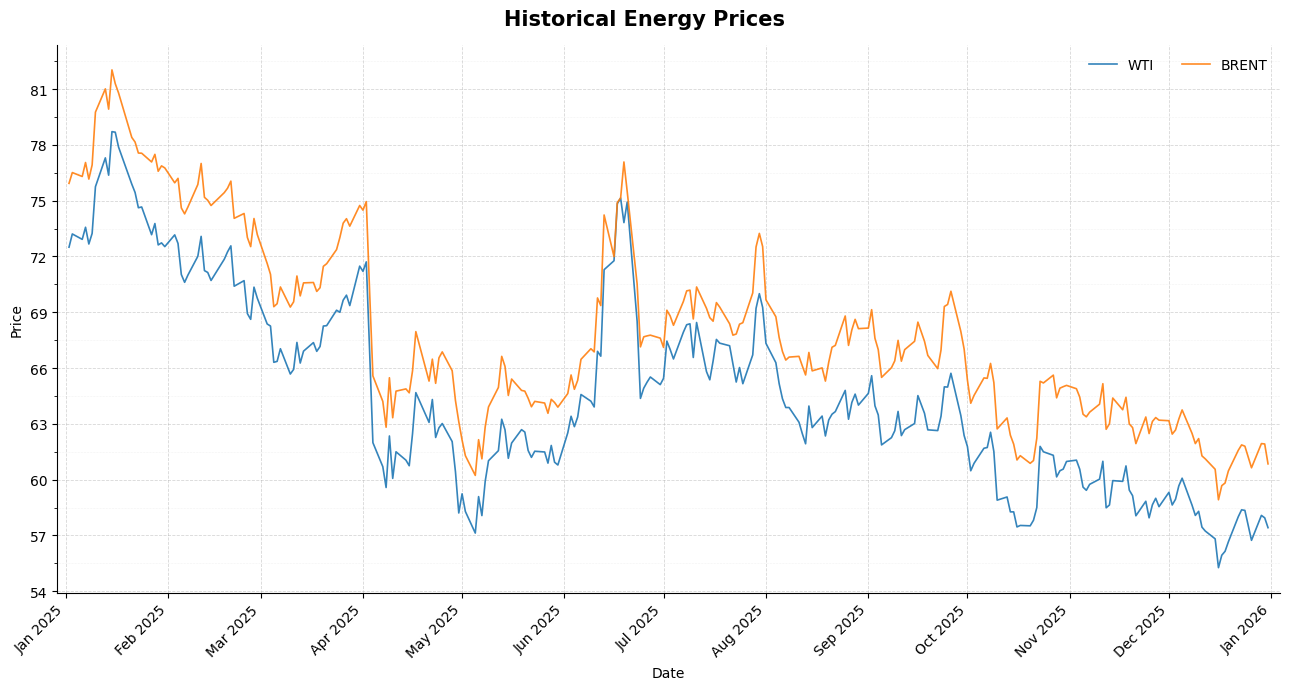

In [9]:
plot_historical_prices(
    plot_name="Historical Energy Prices",
    df=test_df,
    columns=["WTI", "BRENT"],
    output_path=FIGURES_DIR / "brent_wti_prices.png",
    subplots=False,
    date_frequency='monthly'
)